In [2]:
import os
import sys
import numpy as np
import pandas as pd
from scipy import stats
import shap

In [ ]:
X = pd.read_pickle('../../data/shap/fuzzy_x_20240106_values.pkl')
shap_values = np.load('../../data/shap/fuzzy_cat_20240106_shap_values.npy')
shap_interaction_values = np.load('../../data/shap/fuzzy_cat_20240106_shap_interaction_values.npy')

In [5]:
X = X.round(4)
shap_values = np.round(shap_values, 4)
shap_interaction_values = np.round(shap_interaction_values, 4)

In [6]:
variable_A_name = "Sh_3(mu)"
variable_A_index = X.columns.get_loc(variable_A_name)
variable_B_name = "Tipo P"
variable_B_index = X.columns.get_loc(variable_B_name)

In [7]:
from cgt_perezsechi.exploration.sampling import sample_size_kruskal_wallis

sample_size = sample_size_kruskal_wallis(X, shap_values, variable_A_name, acceleration=1)
if sample_size < len(X) / 10:
    sample_size = len(X) // 10

In [8]:
from cgt_perezsechi.manipulation.coding import code_interval

X_coded = code_interval(X, variable_A_name, sample_size)
df_A = pd.DataFrame({
    variable_A_name: X_coded[f'{variable_A_name}_interval'],
    'shap': shap_values[:, X.columns.get_loc(variable_A_name)]
})

In [9]:
df_B = pd.DataFrame({
    variable_B_name: X[variable_B_name],
    'shap': shap_values[:, X.columns.get_loc(variable_B_name)]
})

## Construcción de matrices de adyacencia

In [10]:
shap_interaction_values_A_B = shap_interaction_values[:, variable_A_index, variable_B_index]
df_interaction = pd.DataFrame({
    variable_A_name: X_coded[f'{variable_A_name}_interval'],
    variable_B_name: X_coded[variable_B_name],
    'shap_interaction': shap_interaction_values_A_B
})
df_interaction_grouped = df_interaction.groupby([variable_A_name, variable_B_name]).agg(["mean"]).reset_index()
df_interaction_grouped.columns = [variable_A_name, variable_B_name, 'shap_interaction']
df_interaction_grouped

,Sh_3(mu),Tipo P,shap_interaction
0,"[0.0,0.1065]",0,-961.132634
1,"[0.0,0.1065]",1,1610.446232
2,"[0.1065,0.1692]",0,-16.985293
3,"[0.1065,0.1692]",1,72.576687
4,"[0.1693,0.2133]",0,243.341104
5,"[0.1693,0.2133]",1,-432.708678
6,"[0.2133,0.2562]",0,129.699159
7,"[0.2133,0.2562]",1,-252.518194
8,"[0.2566,0.3032]",0,195.750094
9,"[0.2566,0.3032]",1,-374.690739


In [11]:
unique_A_values = df_interaction_grouped[variable_A_name].unique()
unique_B_values = df_interaction_grouped[variable_B_name].unique()
variable_A_column_names = [f"{variable_A_name}_{value}" for value in unique_A_values]
variable_B_column_names = [f"{variable_B_name}_{value}" for value in unique_B_values]
column_names = variable_A_column_names + variable_B_column_names
r = pd.DataFrame(
    columns=column_names,
)

for A_value in unique_A_values:
    for B_value in unique_B_values:
        index_A = f"{variable_A_name}_{A_value}" 
        index_B = f"{variable_B_name}_{B_value}" 
        shap_interaction = df_interaction_grouped[
            (df_interaction_grouped[variable_A_name] == A_value) &
            (df_interaction_grouped[variable_B_name] == B_value)
        ]['shap_interaction'].values[0]
        r.loc[index_A, index_B] = shap_interaction
        r.loc[index_B, index_A] = shap_interaction

r.replace(np.nan, 0, inplace=True)
r_1 = r

/tmp/ipykernel_51129/2317974099.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  r.replace(np.nan, 0, inplace=True)


In [12]:
r_1

,"Sh_3(mu)_[0.0,0.1065]","Sh_3(mu)_[0.1065,0.1692]","Sh_3(mu)_[0.1693,0.2133]","Sh_3(mu)_[0.2133,0.2562]","Sh_3(mu)_[0.2566,0.3032]","Sh_3(mu)_[0.3032,0.3653]","Sh_3(mu)_[0.3657,0.6572]",Tipo P_0,Tipo P_1
"Sh_3(mu)_[0.0,0.1065]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-961.132634,1610.446232
Tipo P_0,-961.132634,-16.985293,243.341104,129.699159,195.750094,300.885121,1354.072683,0.000000,0.000000
Tipo P_1,1610.446232,72.576687,-432.708678,-252.518194,-374.690739,-327.229931,-2048.313824,0.000000,0.000000
"Sh_3(mu)_[0.1065,0.1692]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-16.985293,72.576687
"Sh_3(mu)_[0.1693,0.2133]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,243.341104,-432.708678
"Sh_3(mu)_[0.2133,0.2562]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,129.699159,-252.518194
"Sh_3(mu)_[0.2566,0.3032]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,195.750094,-374.690739
"Sh_3(mu)_[0.3032,0.3653]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,300.885121,-327.229931
"Sh_3(mu)_[0.3657,0.6572]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1354.072683,-2048.313824


## Representación en grafo de la interacción entre valores de las variables "age" y "sex_isFemale"

In [13]:
df_A_stats = df_A.groupby(variable_A_name).agg(['mean']).reset_index()
df_A_stats.columns = [variable_A_name, 'shap']
df_B_stats = df_B.groupby(variable_B_name).agg(['mean']).reset_index()
df_B_stats.columns = [variable_B_name, 'shap']

In [14]:
df_A_stats

,Sh_3(mu),shap
0,"[0.0,0.1065]",-45018.008511
1,"[0.1065,0.1692]",-29819.632971
2,"[0.1693,0.2133]",-16083.537715
3,"[0.2133,0.2562]",2295.823997
4,"[0.2566,0.3032]",5111.150036
5,"[0.3032,0.3653]",27062.915662
6,"[0.3657,0.6572]",104331.562224


In [15]:
psi_1 = pd.DataFrame(
    columns=['value'],
)

for index, row in df_A_stats.iterrows():
    psi_1.loc[f'{variable_A_name}_{row[variable_A_name]}', 'value'] = row['shap']
for index, row in df_B_stats.iterrows():
    psi_1.loc[f'{variable_B_name}_{row[variable_B_name]:.0f}', 'value'] = row['shap']

psi_1.index.name = None
psi_1

,value
"Sh_3(mu)_[0.0,0.1065]",-45018.008511
"Sh_3(mu)_[0.1065,0.1692]",-29819.632971
"Sh_3(mu)_[0.1693,0.2133]",-16083.537715
"Sh_3(mu)_[0.2133,0.2562]",2295.823997
"Sh_3(mu)_[0.2566,0.3032]",5111.150036
"Sh_3(mu)_[0.3032,0.3653]",27062.915662
"Sh_3(mu)_[0.3657,0.6572]",104331.562224
Tipo P_0,-12265.838634
Tipo P_1,20139.475231


In [16]:
from cgt_perezsechi.manipulation.norm import normalize_psi, normalize_r

psi_2 = normalize_psi(psi_1)
r_2 = normalize_r(r_1)

/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/manipulation/norm.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  max_edge_width = r.applymap(lambda x: abs(x)).max().max()
/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/manipulation/norm.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  r = r.copy().applymap(lambda x: x / max_edge_width)


In [17]:
import regex as re
# Create new column names with TeX expressions
r_2_cols = r_2.columns.str.replace('Sh_3(mu)_', r'Sh_3(\mu) \in ').str.replace(r'^|$', '$', regex=True)
r_2_cols = r_2_cols.str.replace('Tipo P_1', 'Type = Innovative') 
r_2_cols = r_2_cols.str.replace('Tipo P_0', 'Type = Non-Innovative') 
r_2.columns = r_2_cols

# Update index as well
r_2.index = r_2.index.str.replace('Sh_3(mu)_', r'Sh_3(\mu) \in ').str.replace(r'^|$', '$', regex=True)
r_2.index = r_2.index.str.replace('Tipo P_1', 'Type = Innovative')
r_2.index = r_2.index.str.replace('Tipo P_0', 'Type = Non-Innovative')

# Update psi_2 index
psi_2.index = psi_2.index.str.replace('Sh_3(mu)_', r'Sh_3(\mu) \in ').str.replace(r'^|$', '$', regex=True)
psi_2.index = psi_2.index.str.replace('Tipo P_1', 'Type = Innovative')
psi_2.index = psi_2.index.str.replace('Tipo P_0', 'Type = Non-Innovative')

In [18]:
r_2

,"$Sh_3(\mu) \in [0.0,0.1065]$","$Sh_3(\mu) \in [0.1065,0.1692]$","$Sh_3(\mu) \in [0.1693,0.2133]$","$Sh_3(\mu) \in [0.2133,0.2562]$","$Sh_3(\mu) \in [0.2566,0.3032]$","$Sh_3(\mu) \in [0.3032,0.3653]$","$Sh_3(\mu) \in [0.3657,0.6572]$",$Type = Non-Innovative$,$Type = Innovative$
"$Sh_3(\mu) \in [0.0,0.1065]$",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.469231,0.786230
$Type = Non-Innovative$,-0.469231,-0.008292,0.118801,0.063320,0.095566,0.146894,0.661067,0.000000,0.000000
$Type = Innovative$,0.786230,0.035432,-0.211251,-0.123281,-0.182926,-0.159756,-1.000000,0.000000,0.000000
"$Sh_3(\mu) \in [0.1065,0.1692]$",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.008292,0.035432
"$Sh_3(\mu) \in [0.1693,0.2133]$",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.118801,-0.211251
"$Sh_3(\mu) \in [0.2133,0.2562]$",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.063320,-0.123281
"$Sh_3(\mu) \in [0.2566,0.3032]$",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.095566,-0.182926
"$Sh_3(\mu) \in [0.3032,0.3653]$",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.146894,-0.159756
"$Sh_3(\mu) \in [0.3657,0.6572]$",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.661067,-1.000000


In [19]:
psi_2

,value
"$Sh_3(\mu) \in [0.0,0.1065]$",-0.431490
"$Sh_3(\mu) \in [0.1065,0.1692]$",-0.285816
"$Sh_3(\mu) \in [0.1693,0.2133]$",-0.154158
"$Sh_3(\mu) \in [0.2133,0.2562]$",0.022005
"$Sh_3(\mu) \in [0.2566,0.3032]$",0.048989
"$Sh_3(\mu) \in [0.3032,0.3653]$",0.259393
"$Sh_3(\mu) \in [0.3657,0.6572]$",1.000000
$Type = Non-Innovative$,-0.117566
$Type = Innovative$,0.193033


In [20]:
shap_cmap = shap.plots.colors.red_blue
positive_color = shap_cmap(1.0)[:3]
negative_color = shap_cmap(0.0)[:3]

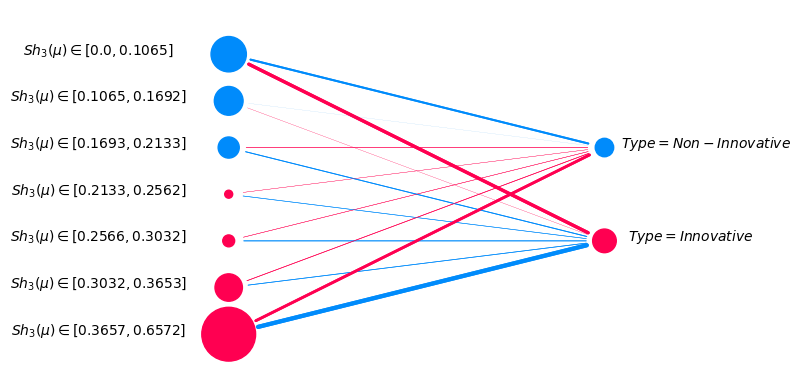

In [32]:
from cgt_perezsechi.visualization.graph import draw

positive_alpha = 0
negative_alpha = 0
positive_beta = 0
negative_beta = 0
draw(
    psi=psi_2,
    r=r_2,
    positive_alpha=positive_alpha,
    negative_alpha=negative_alpha,
    positive_beta=positive_beta,
    negative_beta=negative_beta,
    positive_color=positive_color,
    negative_color=negative_color,
    layout="shell",
    node_label_size_limit=5000,
    node_pos={
        r'$Type = Non-Innovative$': (350, 500),
        r'$Type = Innovative$': (350, 300),
        r'$Sh_3(\mu) \in [0.0,0.1065]$': (90, 700),
        r'$Sh_3(\mu) \in [0.1065,0.1692]$': (90, 600),
        r'$Sh_3(\mu) \in [0.1693,0.2133]$': (90, 500),
        r'$Sh_3(\mu) \in [0.2133,0.2562]$': (90, 400),
        r'$Sh_3(\mu) \in [0.2566,0.3032]$': (90, 300),
        r'$Sh_3(\mu) \in [0.3032,0.3653]$': (90, 200),
        r'$Sh_3(\mu) \in [0.3657,0.6572]$': (90, 100),
    },
    label_pos={
        r'$Type = Non-Innovative$': (420, 500),
        r'$Type = Innovative$': (410, 300),
        r'$Sh_3(\mu) \in [0.0,0.1065]$': (0, 700),
        r'$Sh_3(\mu) \in [0.1065,0.1692]$': (0, 600),
        r'$Sh_3(\mu) \in [0.1693,0.2133]$': (0, 500),
        r'$Sh_3(\mu) \in [0.2133,0.2562]$': (0, 400),
        r'$Sh_3(\mu) \in [0.2566,0.3032]$': (0, 300),
        r'$Sh_3(\mu) \in [0.3032,0.3653]$': (0, 200),
        r'$Sh_3(\mu) \in [0.3657,0.6572]$': (0, 100),
    },
    plot_margin=0.1,
    label_color="#000000",
    # output_path="../output/kw_sh_3_fuzzy_cat_20240106.jpg",
)